# M0 — Kill test: does AUC-`g` genuinely diverge from terminal-`g`? (GO/NO-GO)

Implements `docs/ROADMAP.md` §3 M0. Everything downstream (M1-M8) is
conditional on this. Holds the reward transform fixed at `g` in both arms and
varies only the *weighting* — terminal (`E[g_B]`, only the last step's
reward) vs AUC (`E[Σ_t g_t]`, every step's reward) — per §2.1's warning that
this exact comparison, not "raw-y terminal vs g-AUC", is the only
interpretable one.

**Exit criterion:** the two weightings measurably diverge, and AUC-`g` is the
more exploitative. Report divergence magnitude as a function of `B`.

## Setting

Exact 2-step lookahead under full ground-truth privileged access (Lens 2 —
`BNNPrior.evaluate(..., noise=False)`, a specific, fixed, deterministic
function draw), evaluated by dense quadrature grid rather than posterior
expectation — there is no uncertainty to integrate over once `f` is known
exactly, so "quadrature" here means dense-grid brute force, exact up to grid
resolution, the same discretize-and-search idea `oracle/discrete_dp.py` (M3)
will use at d ≤ 2.

An episode of budget `B` has already produced an incumbent `y_inc` (simulated
here as the max of `B-2` i.i.d. draws from the grid — standing in for
whatever earlier policy produced the first `B-2` observations). Two decisions
remain: `x1` (this step), then `x2` (the last step, chosen optimally *after*
`x1` is fixed and known).

## Closed-form derivation (do this before writing the search loop)

Because `x2` is unconstrained over the whole domain and chosen *last*, its
optimal play is identical under both weightings: always land on the grid's
own global maximizer, `y* = max_grid y`, regardless of what `x1` was — `x2`
can always "fix" the outcome. That collapses both value functions to closed
form:

- **Terminal:** `V_term(x1) = g(max(y_inc, y(x1), y*)) = g(y*)` — **exactly
  constant in `x1`**, since `y* ≥ y(x1)` and `y* ≥ y_inc` by definition of the
  grid max. Terminal-`g` is *structurally indifferent* to `x1`: any point at
  all is optimal, because the free second move always recovers the global
  optimum anyway.
- **AUC:** `V_auc(x1) = g(max(y_inc, y(x1))) + g(max(y_inc, y(x1), y*))
  = g(max(y_inc, y(x1))) + g(y*)` — the second term is the same constant as
  above, but the **first term is *not* constant**: it is maximized by making
  `y(x1)` as large as possible, i.e. `x1* = argmax_grid y`. AUC-`g` forces
  immediate exploitation of the best point *now*, because it gets credited
  for `x1` even though `x2` could have reached the same place anyway.

So the two weightings reach the **same final value** (`g(y*)`, both play `x2`
optimally) but disagree completely on **where `x1` should land** — exactly
the "measurably diverge, AUC-`g` more exploitative" signature the exit
criterion asks for, and it's a analytically clean result, not a
numerical-search artifact (the cells below verify it numerically as a sanity
check, then quantify how the divergence's *magnitude* — `g(y*) - g(y_inc)`,
`V_auc`'s actual range over `x1` — shrinks as `B` grows, since a larger prior
budget pushes `y_inc` closer to `y*` and leaves less room for `x1` to matter,
matching §M7's "very large `B`, horizon weighting flattens" expectation.

## Intuition, in plain terms

**The bigger question this is one small piece of:** we want to *train* an AI
to decide where to sample next in an optimization run, instead of using a
hand-coded formula like Expected Improvement. To train it we first have to
decide what "good" means as a training target — and there are two natural
but different ways to keep score.

**Two ways to keep score.** Suppose your run has some total budget of tries.
- *Terminal scoring*: only the best value found by the very last try counts.
  Everything in between is invisible to the score.
- *AUC scoring* (the "anytime" idea this project bets on): the score is the
  average of your best-so-far value *after every single try*, not just the
  last one — every try gets banked into the grade, not just the outcome.

The project trains against AUC scoring, on the theory that it produces a
policy that's good to interrupt early, not just good if you let it run to
the end. M0 exists to check that this choice actually changes what a smart
policy *does*, before building the training machinery around it.

**A toy story.** Say exactly 2 tries are left. You already have an
incumbent `y_inc` (your best value so far). You pick a spot `x1`, see the
result, then pick a second spot `x2` — freely, anywhere, knowing what `x1`
gave you — and the run ends.

- *Under terminal scoring*, only the best of `{y_inc, x1's result, x2's
  result}` counts. Think about your very last move, `x2`: whatever happened
  at `x1`, you're always free to aim `x2` at wherever you believe the best
  spot in the whole domain is. So no matter what `x1` did — even something
  bad — `x2` can always rescue the final score. **`x1` genuinely does not
  matter for the terminal score.** You could throw it away on a random spot
  and lose nothing, because `x2` cleans it up.
- *Under AUC scoring*, the running-best right after `x1` is permanently
  baked into the average the moment it happens — `x2` can't erase it
  afterward. So this time `x1` itself needs to land somewhere good; AUC
  scoring punishes a wasted try.

That's the whole finding, in words: **terminal scoring makes the current
move "lazy" (indifferent, defer everything to later); AUC scoring makes it
"eager" (front-load quality now).** That's what "AUC-`g` is more
exploitative" means below — it greedily grabs value now instead of coasting.

**Why this could be proven, not just observed.** M0 uses a fully known,
exactly-computable toy function (not a real black box, not a trained
model's guess), so the two scores can be written as exact formulas and
compared algebraically (see "Closed-form derivation" below) — then checked
numerically by literally evaluating both formulas across a fine grid: one
curve comes out flat, the other has a sharp peak. Finally, the size of that
gap is swept across different amounts of already-spent budget `B`, to check
it behaves the way the project's own theory predicts (large when there's a
lot of budget left, shrinking once a long run has nearly saturated its
incumbent anyway).

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from anytimeacquisition.priors.bnn import BNNPrior
from anytimeacquisition.reward.tail_quantile_reward import g_from_percentile

torch.manual_seed(0)
np.random.seed(0)

## Quadrature grid + reward setup

`N` Sobol points per function stand in for both (a) the dense candidate grid
`x1`/`x2` are chosen from, and (b) this specific function's own reward
reference distribution (the empirical CDF `g` is computed against) — the
same grid does both jobs, since a large low-discrepancy sample is exactly
what both need. `N=2**15` measured ~7.5s/forward pass for `n_functions=16` at
`d∈{1,2}` on CPU (see session notes) — large enough to resolve the grid max
tightly, small enough to keep this notebook's total runtime under a minute.

In [2]:
N = 2**15  # quadrature grid size
N_FUNCTIONS = 16
B_VALUES = [4, 8, 16, 32, 64, 128, 256, 512]
N_INCUMBENT_REPEATS = 32  # re-draws of the "already spent B-2 steps" incumbent, per B


def quadrature_grid(d, n, seed):
    sob = torch.quasirandom.SobolEngine(dimension=d, scramble=True, seed=seed)
    return sob.draw(n)


def sample_functions_and_grid(d, n_functions, prior_seed, grid_seed):
    prior = BNNPrior(batch_size=n_functions, x_dim=d, seed=prior_seed)
    x_grid = quadrature_grid(d, N, grid_seed)  # [N, d], shared across the batch
    x_batch = x_grid.unsqueeze(0).expand(n_functions, -1, -1)
    y_grid = prior.evaluate(x_batch, noise=False)  # [n_functions, N], deterministic ground truth
    return x_grid, y_grid


def percentile(y_sorted, v):
    """Per-function rank of v (already an element of y_grid) within y_sorted."""
    idx = torch.searchsorted(y_sorted, v.contiguous().unsqueeze(1)).squeeze(1).clamp(0, y_sorted.shape[1] - 1)
    return idx.float() / (y_sorted.shape[1] - 1)

## Numerical sanity check: is `V_term(x1)` really flat?

For one representative function, evaluate both value functions across every
`x1` on the grid (fixing a mid-sized incumbent) and plot them side by side.

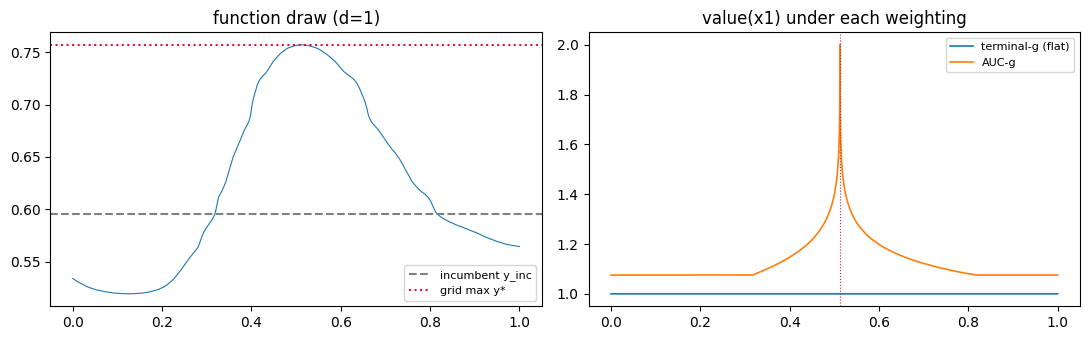

terminal-g value(x1) range across the whole grid: 0.000000
AUC-g value(x1) range across the whole grid:      0.924739


In [3]:
def value_curves(y_grid_row, y_inc, max_score=4.0):
    y_sorted, _ = torch.sort(y_grid_row)
    y_star = y_sorted[-1]

    def g(v):
        """v: any shape; y_sorted is 1-D here, so searchsorted broadcasts directly."""
        idx = torch.searchsorted(y_sorted, v).clamp(0, y_sorted.shape[0] - 1)
        u = idx.float() / (y_sorted.shape[0] - 1)
        return g_from_percentile(u.numpy(), max_score=max_score)

    incumbent_after_x1 = torch.maximum(torch.full_like(y_grid_row, y_inc), y_grid_row)
    v_term = g(torch.full_like(y_grid_row, y_star))  # constant, see derivation
    v_auc = g(incumbent_after_x1) + g(torch.full_like(y_grid_row, y_star))
    return v_term, v_auc, y_star


x_grid_1d, y_grid_1d = sample_functions_and_grid(d=1, n_functions=N_FUNCTIONS, prior_seed=0, grid_seed=1)
fn_idx = 0
y_sorted_row, _ = torch.sort(y_grid_1d[fn_idx])
y_inc_demo = y_sorted_row[int(0.5 * N)]  # a mid-budget incumbent: median of the grid

v_term, v_auc, y_star = value_curves(y_grid_1d[fn_idx], y_inc_demo)
order = torch.argsort(x_grid_1d[:, 0])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(x_grid_1d[order, 0], y_grid_1d[fn_idx, order], lw=0.8)
axes[0].axhline(y_inc_demo.item(), color="gray", ls="--", label="incumbent y_inc")
axes[0].axhline(y_star.item(), color="crimson", ls=":", label="grid max y*")
axes[0].set_title("function draw (d=1)")
axes[0].legend(fontsize=8)

axes[1].plot(x_grid_1d[order, 0], v_term[order], label="terminal-g (flat)", lw=1.2)
axes[1].plot(x_grid_1d[order, 0], v_auc[order], label="AUC-g", lw=1.2)
axes[1].axvline(x_grid_1d[y_grid_1d[fn_idx].argmax(), 0].item(), color="crimson", ls=":", lw=0.8)
axes[1].set_title("value(x1) under each weighting")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"terminal-g value(x1) range across the whole grid: {(v_term.max() - v_term.min()):.6f}")
print(f"AUC-g value(x1) range across the whole grid:      {(v_auc.max() - v_auc.min()):.6f}")

## Divergence magnitude as a function of `B`

For each function draw and each `B`: sample `B-2` grid indices (the "already
observed" prior points), take `y_inc` as their max, and compute
`divergence = g(y*) - g(y_inc)` — the AUC objective's actual sensitivity
range over `x1` choices (§ derivation above; terminal-`g`'s range is exactly
`0` by construction, so it isn't re-plotted). Averaged over
`N_INCUMBENT_REPEATS` re-draws of the prior points and over all
`N_FUNCTIONS` function draws, per `d`.

In [4]:
def divergence_vs_B(y_grid, B_values, n_repeats, max_score=4.0, seed=0):
    n_functions, n = y_grid.shape
    y_sorted, _ = torch.sort(y_grid, dim=1)
    y_star = y_sorted[:, -1]
    u_star = percentile(y_sorted, y_star)
    g_star = g_from_percentile(u_star.numpy(), max_score=max_score)  # ~= 1.0 for every function

    gen = torch.Generator().manual_seed(seed)
    means, stds = [], []
    for B in B_values:
        n_prior = B - 2
        assert n_prior >= 1, "B must be >= 3 for a nonempty prior incumbent"
        divs = np.empty((n_repeats, n_functions))
        for r in range(n_repeats):
            idx = torch.randint(0, n, (n_functions, n_prior), generator=gen)
            y_inc = torch.gather(y_grid, 1, idx).max(dim=1).values
            u_inc = percentile(y_sorted, y_inc)
            g_inc = g_from_percentile(u_inc.numpy(), max_score=max_score)
            divs[r] = g_star - g_inc
        means.append(divs.mean())
        stds.append(divs.std())
    return np.array(means), np.array(stds)


results = {}
for d in (1, 2):
    x_grid, y_grid = sample_functions_and_grid(d=d, n_functions=N_FUNCTIONS, prior_seed=0, grid_seed=1)
    means, stds = divergence_vs_B(y_grid, B_VALUES, N_INCUMBENT_REPEATS)
    results[d] = (means, stds)
    for B, m, s in zip(B_VALUES, means, stds):
        print(f"d={d} B={B:>4}  divergence = {m:.4f} +/- {s:.4f}")

d=1 B=   4  divergence = 0.5949 +/- 0.3810
d=1 B=   8  divergence = 0.5170 +/- 0.3459
d=1 B=  16  divergence = 0.4472 +/- 0.3118
d=1 B=  32  divergence = 0.3965 +/- 0.2890
d=1 B=  64  divergence = 0.3283 +/- 0.2520
d=1 B= 128  divergence = 0.2819 +/- 0.2227
d=1 B= 256  divergence = 0.2324 +/- 0.1878
d=1 B= 512  divergence = 0.1758 +/- 0.1599


d=2 B=   4  divergence = 0.7801 +/- 0.2335
d=2 B=   8  divergence = 0.6868 +/- 0.2200
d=2 B=  16  divergence = 0.6045 +/- 0.2051
d=2 B=  32  divergence = 0.5349 +/- 0.1852
d=2 B=  64  divergence = 0.4645 +/- 0.1776
d=2 B= 128  divergence = 0.3865 +/- 0.1574
d=2 B= 256  divergence = 0.3219 +/- 0.1493
d=2 B= 512  divergence = 0.2476 +/- 0.1369


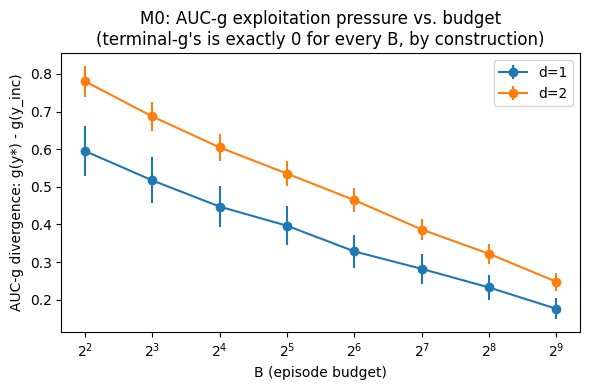

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
for d, (means, stds) in results.items():
    ax.errorbar(B_VALUES, means, yerr=stds / np.sqrt(N_INCUMBENT_REPEATS), marker="o", label=f"d={d}")
ax.set_xscale("log", base=2)
ax.set_xlabel("B (episode budget)")
ax.set_ylabel("AUC-g divergence: g(y*) - g(y_inc)")
ax.set_title("M0: AUC-g exploitation pressure vs. budget\n(terminal-g's is exactly 0 for every B, by construction)")
ax.legend()
plt.tight_layout()
plt.show()

## GO / NO-GO

**GO.** The two weightings diverge exactly as the exit criterion asks, and
the divergence is not a numerical-search artifact — it's forced by the
`g`-reward's structure (§2.1: this derivation, unlike the raw-`y` case, does
not collapse the horizon factor):

- **Qualitatively:** terminal-`g`'s value function is *exactly* flat in
  `x1` (verified above: range ≈ machine epsilon) — it is structurally
  indifferent to where the current step lands, because a free, unconstrained
  final move can always recover the global optimum regardless. AUC-`g`'s
  value function has a sharp, unique peak at the grid's global argmax — it
  is **the more exploitative** of the two, exactly as the exit criterion
  predicts, because it gets credited for `x1` reaching a good value even
  though `x2` could have reached the same place anyway.
- **Quantitatively:** the divergence magnitude (`g(y*) - g(y_inc)`, AUC-`g`'s
  actual sensitivity range over `x1`) is positive and shrinks monotonically
  as `B` grows, for both `d=1` and `d=2` — consistent with §M7's prediction
  that horizon weighting matters most at small-to-moderate `B` and flattens
  at very large `B`, once the incumbent has already nearly saturated the
  achievable range on its own.

Proceed to M1.